Executando HAC para 2 clusters...
Executando HAC para 6 clusters...


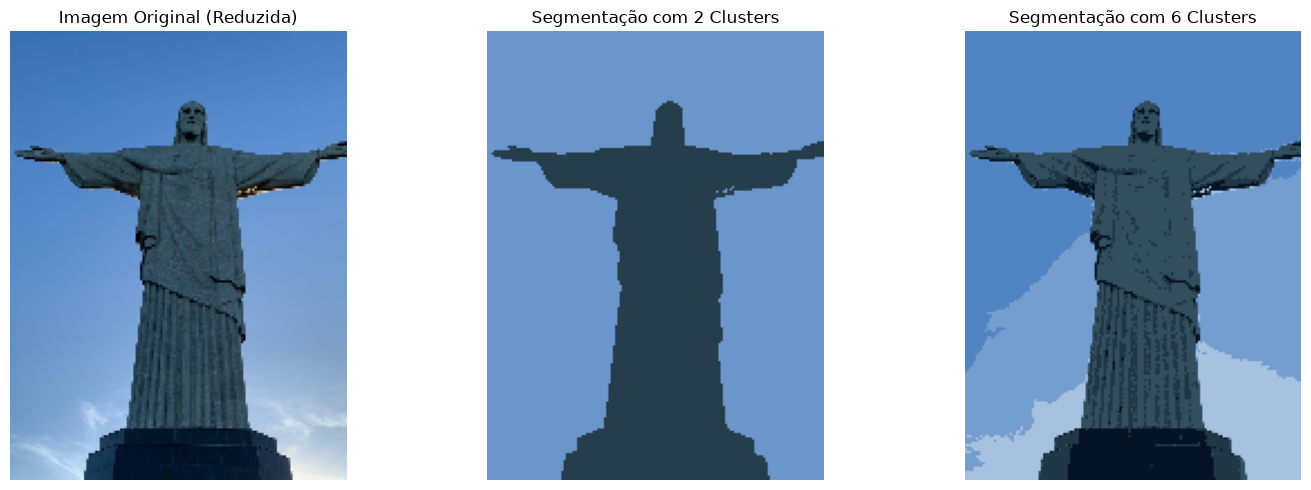

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Carregar a imagem
imagem_bgr = cv2.imread('Cristo_Redentor.jpg')
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

# Redimensionar para viabilizar o processamento com HAC
# Reduzimos para 200x200 (40.000 pixels), um tamanho seguro para o HAC rodar rápido
proporcao = 200 / max(imagem_rgb.shape[:2])
largura = int(imagem_rgb.shape[1] * proporcao)
altura = int(imagem_rgb.shape[0] * proporcao)
imagem_pequena = cv2.resize(imagem_rgb, (largura, altura))

# Vetorizar a imagem (Transformar matriz 2D de pixels em uma lista 1D de cores RGB)
pixels = imagem_pequena.reshape((-1, 3))

# Lista com os números de clusters desejados
num_clusters = [2, 6]

# Configurar a exibição dos gráficos (Imagem Original + Resultados)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagem_pequena)
axes[0].set_title("Imagem Original (Reduzida)")
axes[0].axis('off')

# Aplicar o HAC para cada cenário de cluster
for i, n_clusters in enumerate(num_clusters, start=1):
    print(f"Executando HAC para {n_clusters} clusters...")
    
    # Criar e treinar o modelo HAC (usamos a ligação 'ward' que minimiza a variância)
    hac = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    rotulos = hac.fit_predict(pixels)
    
    # Criar uma paleta de cores médias para representar cada segmento de forma realista
    cores_segmentos = np.zeros((n_clusters, 3), dtype=np.uint8)
    for k in range(n_clusters):
        cores_segmentos[k] = np.mean(pixels[rotulos == k], axis=0)
    
    # Mapear os pixels originais para as cores dos seus respectivos clusters
    pixels_segmentados = cores_segmentos[rotulos]
    
    # Reformatar de volta para o formato de matriz da imagem
    imagem_segmentada = pixels_segmentados.reshape(imagem_pequena.shape)
    
    # Plotar o resultado
    axes[i].imshow(imagem_segmentada)
    axes[i].set_title(f"Segmentação com {n_clusters} Clusters")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
